# 기능 엔지니어링

이전 장에서는 머신러닝(Machine Learning)의 기본 개념을 설명했지만 모든 예제에서는 깔끔한 `[n_samples, n_features]` 형식의 숫자 데이터가 있다고 가정했습니다.
현실 세계에서는 이런 형태로 데이터가 나오는 경우가 거의 없습니다.
이를 염두에 두고 실제로 머신러닝(Machine Learning)을 사용하는 데 있어 더 중요한 단계 중 하나는 *특성 엔지니어링*입니다. 즉, 문제에 대해 가지고 있는 모든 정보를 가져와 특성 행렬를 구축하는 데 사용할 수 있는 숫자로 바꾸는 것입니다.

이번 장에서는 기능 엔지니어링 작업의 몇 가지 일반적인 예를 다룰 것입니다. 즉, 범주형 데이터, 텍스트 및 이미지를 나타내는 기능을 살펴보겠습니다.
또한, 모델 복잡성을 증가시키고 누락된 데이터를 대치하기 위해 파생된 기능에 대해 논의할 것입니다.
이 프로세스는 임의의 데이터를 선의로 동작하는 벡터로 변환하는 작업을 포함하므로 일반적으로 벡터화라고 합니다.

## 범주형 기능

숫자가 아닌 데이터의 일반적인 유형 중 하나는 *범주형* 데이터입니다.
예를 들어 주택 가격에 대한 일부 데이터를 탐색 중이고 "가격" 및 "객실"과 같은 숫자 특성과 함께 "이웃" 정보도 있다고 가정해 보겠습니다.
예를 들어 데이터는 다음과 같을 수 있습니다.

In [1]:
data = [
    {"price": 850000, "rooms": 4, "neighborhood": "Queen Anne"},
    {"price": 700000, "rooms": 3, "neighborhood": "Fremont"},
    {"price": 650000, "rooms": 3, "neighborhood": "Wallingford"},
    {"price": 600000, "rooms": 2, "neighborhood": "Fremont"},
]

간단한 숫자 매핑을 사용하여 이 데이터를 인코딩하고 싶을 수도 있습니다.

In [2]:
{"Queen Anne": 1, "Fremont": 2, "Wallingford": 3};

그러나 이는 Scikit-Learn에서는 일반적으로 유용한 접근 방식이 아닌 것으로 나타났습니다. 패키지의 모델은 숫자 특징이 대수적 양을 반영한다는 기본 가정을 하기 때문에 이러한 매핑은 예를 들어 *Queen Anne < Fremont < Wallingford* 또는 심지어 *Wallingford–Queen Anne = Fremont*를 암시합니다. 이는 (틈새 인구학적 농담은 제쳐두고) 별 의미가 없습니다.

이 경우 입증된 기술 중 하나는 *원-핫 인코딩*을 사용하는 것입니다. 이 방법은 각각 값이 1 또는 0인 범주의 존재 여부를 나타내는 추가 열을 효과적으로 생성합니다.
데이터가 사전 목록 형식을 취하는 경우 Scikit-Learn의 ``DictVectorizer``가 이 작업을 수행합니다.

In [3]:
from sklearn.feature_extraction import DictVectorizer

vec = DictVectorizer(sparse=False, dtype=int)
vec.fit_transform(data)

array([[     0,      1,      0, 850000,      4],
       [     1,      0,      0, 700000,      3],
       [     0,      0,      1, 650000,      3],
       [     1,      0,      0, 600000,      2]])

'이웃' 열은 세 개의 이웃 레이블을 나타내는 세 개의 별도 열로 확장되었으며 각 행에는 이웃과 연결된 열에 1이 있습니다.
이렇게 인코딩된 이러한 범주형 기능을 사용하면 Scikit-Learn 모델 피팅을 정상적으로 진행합니다.

각 열의 의미를 보려면 기능 이름을 검사하면 됩니다.

In [4]:
vec.get_feature_names_out()

array(['neighborhood=Fremont', 'neighborhood=Queen Anne',
       'neighborhood=Wallingford', 'price', 'rooms'], dtype=object)

이 접근 방식에는 한 가지 분명한 단점이 있습니다. 카테고리에 가능한 값이 많으면 데이터 세트 크기가 *크게* 늘어날 수 있다는 것입니다.
그러나 인코딩된 데이터에는 대부분 0이 포함되어 있으므로 희소 출력이 매우 효율적인 솔루션이 될 수 있습니다.

In [5]:
vec = DictVectorizer(sparse=True, dtype=int)
vec.fit_transform(data)

<4x5 sparse matrix of type '<class 'numpy.int64'>'
	with 12 stored elements in Compressed Sparse Row format>

거의 모든 Scikit-Learn 추정기는 모델을 맞추고 평가할 때 이러한 희소 입력을 허용합니다. `sklearn.preprocessing.OneHotEncoder` 및 `sklearn.feature_extraction.FeatureHasher`는 Scikit-Learn이 이러한 유형의 인코딩을 지원하기 위해 포함하는 두 가지 추가 도구입니다.

## 텍스트 기능

특성 엔지니어링의 또 다른 일반적인 요구 사항은 텍스트를 대표적인 숫자 값 집합으로 변환하는 것입니다.
예를 들어 소셜 미디어 데이터의 대부분의 자동 마이닝은 텍스트를 숫자로 인코딩하는 어떤 형태에 의존합니다.
이러한 유형의 데이터를 인코딩하는 가장 간단한 방법 중 하나는 *단어 수*를 사용하는 것입니다. 즉, 텍스트의 각 조각을 가져와 그 안에 있는 각 단어의 발생 횟수를 세어 결과를 표에 표시합니다.

예를 들어 다음 세 가지 문구 세트를 고려해 보세요.

In [6]:
sample = ["problem of evil", "evil queen", "horizon problem"]

단어 수를 기반으로 이 데이터를 벡터화하기 위해 "문제", "~의", "악" 등의 단어를 나타내는 개별 열을 구성합니다.
이 간단한 예에서는 이 작업을 수동으로 수행하는 것이 가능하지만 Scikit-Learn의 `CountVectorizer`를 사용하면 지루함을 피합니다.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()
X = vec.fit_transform(sample)
X

<3x5 sparse matrix of type '<class 'numpy.int64'>'
	with 7 stored elements in Compressed Sparse Row format>

결과는 각 단어가 나타나는 횟수를 기록하는 희소 행렬입니다. 이를 레이블이 지정된 열이 있는 `DataFrame`으로 변환하면 검사하기가 더 쉽습니다.

In [8]:
import pandas as pd

pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

,evil,horizon,of,problem,queen
0,1,0,1,1,0
1,1,0,0,0,1
2,0,1,0,1,0


그러나 간단한 원시 단어 수를 사용하는 데에는 몇 가지 문제가 있습니다. 매우 자주 나타나는 단어에 너무 많은 가중치를 부여하는 기능이 발생할 수 있으며 일부 분류 알고리즘에서는 이것이 차선책일 수 있습니다.
이 문제를 해결하기 위한 한 가지 접근 방식은 *용어 빈도-역 문서 빈도*(*TF-IDF*)로 알려져 있으며, 이는 문서에 단어가 나타나는 빈도를 측정하여 단어 수에 가중치를 부여합니다.
이러한 기능을 계산하는 구문은 이전 예와 유사합니다.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer()
X = vec.fit_transform(sample)
pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

,evil,horizon,of,problem,queen
0,0.517856,0.000000,0.680919,0.517856,0.000000
1,0.605349,0.000000,0.000000,0.000000,0.795961
2,0.000000,0.795961,0.000000,0.605349,0.000000


분류 문제에서 TF-IDF를 사용하는 예는 [심층: Naive Bayes 분류](05.05-Naive-Bayes.ipynb)를 참조하세요.

## 이미지 특징

또 다른 일반적인 요구 사항은 머신러닝(Machine Learning) 분석을 위해 이미지를 적절하게 인코딩하는 것입니다.
가장 간단한 접근 방식은 [Scikit-Learn 소개](05.02-Introducing-Scikit-Learn.ipynb)에서 숫자 데이터에 사용한 것입니다. 즉, 단순히 픽셀 값 자체를 사용하는 것입니다.
그러나 애플리케이션에 따라 이러한 접근 방식이 최적이 아닐 수도 있습니다.

이미지의 특징 추출 기술에 대한 포괄적인 요약은 이 장의 범위를 훨씬 벗어나지만 [Scikit-Image 프로젝트](http://scikit-image.org)에서 많은 표준 접근 방식의 탁월한 구현을 찾을 수 있습니다.
Scikit-Learn과 Scikit-Image를 함께 사용하는 한 가지 예는 [기능 엔지니어링: 이미지 작업](05.14-Image-Features.ipynb)을 참조하세요.

## 파생 기능

또 다른 유용한 유형의 기능은 일부 입력 기능에서 수학적으로 파생되는 기능입니다.
입력 데이터에서 *다항식 특징*을 구성할 때 [하이퍼 매개변수 및 모델 유효성 검사](05.03-Hyperparameters-and-Model-Validation.ipynb)에서 이에 대한 예를 보았습니다.
우리는 모델을 변경하는 것이 아니라 입력을 변환하여 선형 회귀를 다항식 회귀로 변환할 수 있다는 것을 확인했습니다.

예를 들어 이 데이터는 직선으로는 명확하게 설명할 수 없습니다(그림 40-1 참조).

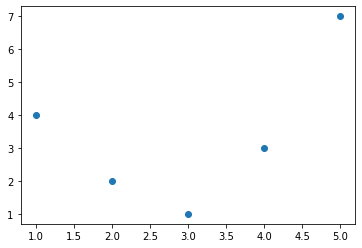

In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5])
y = np.array([4, 2, 1, 3, 7])
plt.scatter(x, y);

그림 40-2와 같이 `LinearRegression`을 사용하여 데이터에 선을 맞추고 최적의 결과를 얻을 수 있습니다.

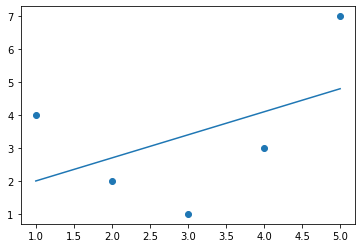

In [11]:
from sklearn.linear_model import LinearRegression

X = x[:, np.newaxis]
model = LinearRegression().fit(X, y)
yfit = model.predict(X)
plt.scatter(x, y)
plt.plot(x, yfit);

하지만 $x$와 $y$ 사이의 관계를 설명하려면 더 정교한 모델이 필요하다는 것은 분명합니다.

이에 대한 한 가지 접근 방식은 데이터를 변환하여 추가 기능 열을 추가하여 모델의 유연성을 높이는 것입니다.
예를 들어 다음과 같은 방법으로 데이터에 다항식 기능을 추가합니다.

In [12]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)
X2 = poly.fit_transform(X)
print(X2)

[[  1.   1.   1.]
 [  2.   4.   8.]
 [  3.   9.  27.]
 [  4.  16.  64.]
 [  5.  25. 125.]]


파생된 특징 행렬에는 $x$를 나타내는 열 하나, $x^2$를 나타내는 두 번째 열, $x^3$을 나타내는 세 번째 열이 있습니다.
이 확장된 입력에 대한 선형 회귀를 계산하면 그림 40-3에서 볼 수 있듯이 데이터에 훨씬 더 가깝게 맞습니다.

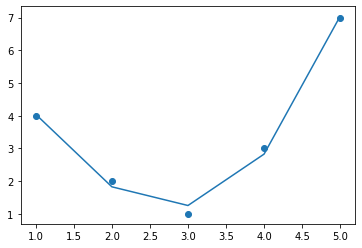

In [13]:
model = LinearRegression().fit(X2, y)
yfit = model.predict(X2)
plt.scatter(x, y)
plt.plot(x, yfit);

모델을 변경하는 것이 아니라 입력을 변환하여 모델을 개선한다는 아이디어는 더 강력한 머신러닝(Machine Learning) 방법의 기본입니다.
*기초 함수 회귀*의 맥락에서 [심층: 선형 회귀](05.06-Linear-Regression.ipynb)에서 이 아이디어를 더 자세히 살펴보겠습니다.
보다 일반적으로 이는 *커널 방법*으로 알려진 강력한 기술 세트에 대한 동기 부여 경로 중 하나이며, 이에 대해서는 [심층: 지원 벡터 머신](05.07-Support-Vector-Machines.ipynb)에서 살펴보겠습니다.

## 누락된 데이터의 대치

기능 엔지니어링의 또 다른 일반적인 요구 사항은 누락된 데이터를 처리하는 것입니다.
[누락된 데이터 처리](03.04-Missing-Values.ipynb)에서 `DataFrame` 객체의 누락된 데이터 처리에 대해 논의했으며, `NaN`이 누락된 값을 표시하는 데 자주 사용되는 것을 확인했습니다.
예를 들어 다음과 같은 데이터 세트가 있습니다.

In [14]:
from numpy import nan

X = np.array([[nan, 0, 3], [3, 7, 9], [3, 5, 2], [4, nan, 6], [8, 8, 1]])
y = np.array([14, 16, -1, 8, -5])

이러한 데이터에 일반적인 머신러닝(Machine Learning) 모델을 적용할 때 먼저 누락된 값을 적절한 채우기 값으로 바꿔야 합니다.
이를 결측값의 *대체*라고 하며, 전략은 단순한 것(예: 결측값을 열의 평균으로 대체)부터 정교한 것(예: 행렬 완성 또는 강력한 모델을 사용하여 이러한 데이터를 처리하는 것)까지 다양합니다.

정교한 접근 방식은 애플리케이션별로 매우 구체적인 경향이 있으므로 여기서는 자세히 다루지 않겠습니다.
평균, 중앙값 또는 가장 빈번한 값을 사용하는 기준 대치 접근 방식의 경우 Scikit-Learn은 'SimpleImputer' 클래스를 제공합니다.

In [15]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="mean")
X2 = imp.fit_transform(X)
X2

array([[4.5, 0. , 3. ],
       [3. , 7. , 9. ],
       [3. , 5. , 2. ],
       [4. , 5. , 6. ],
       [8. , 8. , 1. ]])

결과 데이터에서 두 개의 누락된 값이 열에 있는 나머지 값의 평균으로 대체되었음을 확인합니다. 이 귀속된 데이터는 예를 들어 'LinearRegression' 추정기에 직접 입력될 수 있습니다.

In [16]:
model = LinearRegression().fit(X2, y)
model.predict(X2)

array([13.14869292, 14.3784627 , -1.15539732, 10.96606197, -5.33782027])

## 기능 파이프라인

앞의 예제 중 하나를 사용하면 특히 여러 단계를 함께 연결하려는 경우 수동으로 변환을 수행하는 것이 금방 지루해질 수 있습니다.
예를 들어 다음과 같은 처리 파이프라인이 필요합니다.

1. 평균을 사용하여 결측값을 대치합니다.
2. 특징을 2차로 변환합니다.
3. 선형 회귀 모델을 피팅합니다.

이러한 유형의 처리 파이프라인을 간소화하기 위해 Scikit-Learn은 다음과 같이 사용할 수 있는 ``Pipeline`` 개체를 제공합니다.

In [17]:
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    SimpleImputer(strategy="mean"), PolynomialFeatures(degree=2), LinearRegression()
)

이 파이프라인은 표준 Scikit-Learn 객체처럼 보이고 작동하며 모든 입력 데이터에 지정된 모든 단계를 적용합니다.

In [18]:
model.fit(X, y)  # X with missing values, from above
print(y)
print(model.predict(X))

[14 16 -1  8 -5]
[14. 16. -1.  8. -5.]


모델의 모든 단계가 자동으로 적용됩니다.
단순화를 위해 이 데모에서는 훈련된 데이터에 모델을 적용했습니다. 이것이 결과를 완벽하게 예측할 수 있었던 이유입니다(이에 대한 자세한 내용은 [하이퍼파라미터 및 모델 검증](05.03-Hyperparameters-and-Model-Validation.ipynb)을 참조하세요).

실행 중인 Scikit-Learn 파이프라인의 몇 가지 예는 Naive Bayes 분류에 대한 다음 장과 [심층: 선형 회귀](05.06-Linear-Regression.ipynb) 및 [심층: 지원 벡터 머신](05.07-Support-Vector-Machines.ipynb)을 참조하세요.